In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager
from auditoryforage.utils import plot_AF_episode

# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

Checkpoint (epoch 50) loaded.
Fetching the most trained agent so far (epoch 50).
Agent (seed 1) was trained for 50 epochs, RL optimality 99.95%.


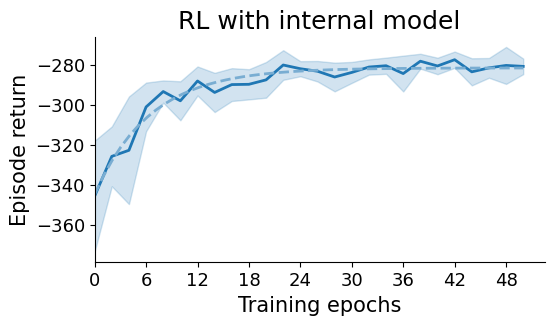

In [3]:
env_param = [-3.0, 12.0, 15, 10, -8, -4]
num_epochs = 50

#Lokesh - added this for recent SB3
seed = 100

#Lokesh - added this for recent SB3
agent = manager.train_agent(env_param, num_epochs=num_epochs)
# agent = manager.train_agent(env_param, seed=seed, num_epochs=num_epochs)

agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

{'experiment': {'prob_01': 0.5,
  'no_signal_nodes': 4,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 1},
 'agent': {'lick_cost': -3.0,
  'food_reward': 12.0,
  'attention_cost_coeff': 15,
  'attention_cost_temp': 10,
  'penalty_cost': -8,
  'iti_cost': -4,
  'no_attention_modes': 3}}

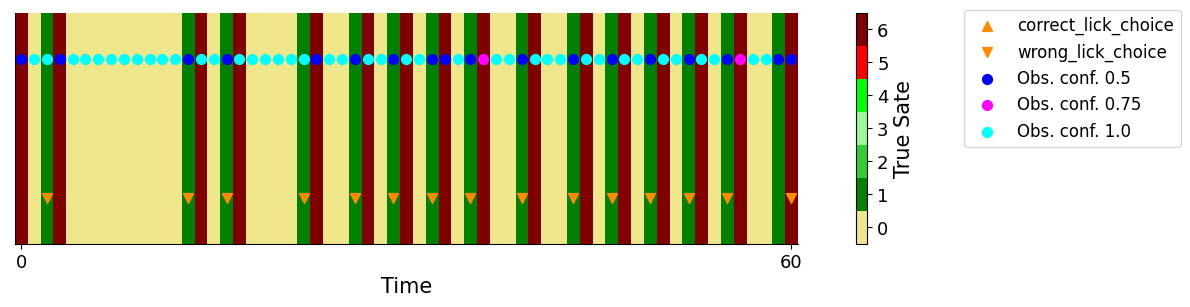

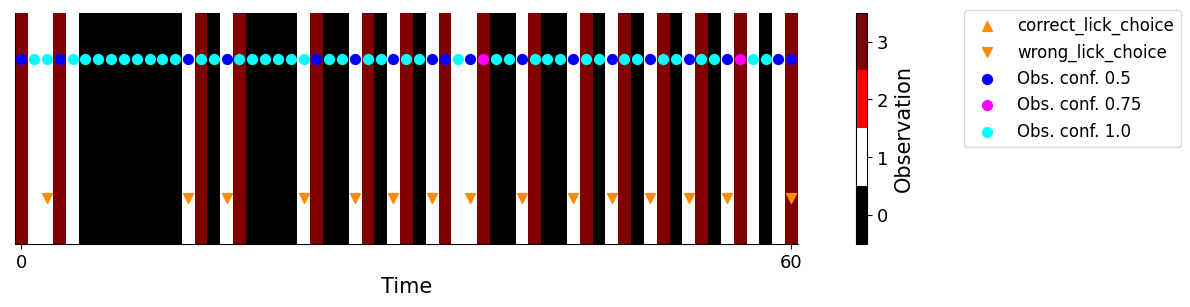

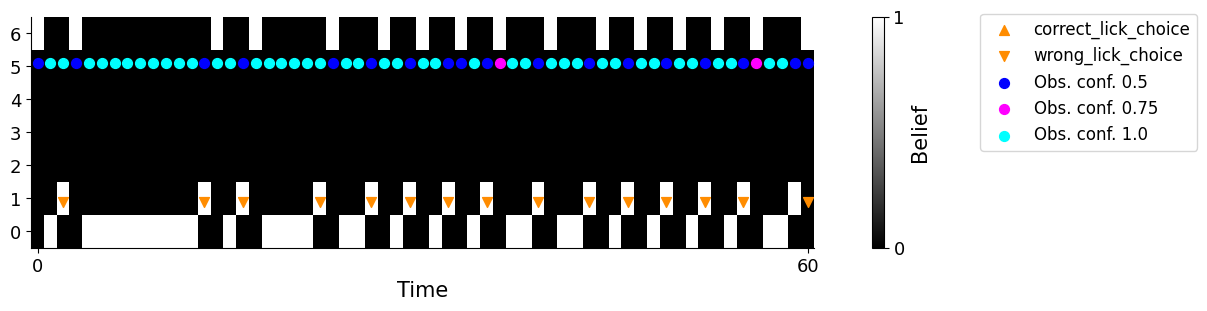

In [4]:
from auditoryforage.AF_env import AuditoryForaging

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'experiment': {'prob_01': 0.5},'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
episode = agent.run_one_episode(env=env, num_steps=60, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env)

env.spec



In [5]:
print(type(episode['beliefs'].astype(float)))

<class 'numpy.ndarray'>


In [6]:
# import torch
# beliefs = episode['beliefs']
# agent.agent_action_distribution(torch.from_numpy(beliefs))

# belief_tensors = episode['belief_tensors']
# agent.agent_action_distribution(belief_tensors)

beliefs = episode['beliefs']
action_distributions = agent.agent_action_distribution(beliefs)


In [9]:
sum(action_distributions[1])

1.0000000179606041